# 13｜dispatch 目标继续：Mandi / SPO+ / DBB / 集成同场比

**目的**：12 的窗 CE 证明 dispatch 对齐 **work**（LSTM 4554 → 6301），但相对 oracle 9000 只多拿约 1 个 capture 点。CE 只把一个 oracle 窗推到第一。本册换 surrogate，不换合同、不换 LSTM 头，同场比四条文献损失加一条 30 日 realized 选权的集成。

**输入**：

- 冻住 11/12：`reports/holdout_rmse_v1/leaderboard.csv`、v2 同名、`reports/holdout_dispatch_loss_v1/leaderboard.csv` 与 predictions
- 本试验：`reports/holdout_dfl_bakeoff_v1/`（没有则跑 `experiments/holdout_dfl_bakeoff_v1/run.py`）

**五条新配方**（骨干一律 CompactDayLSTM + contextual，除非是集成）：

1. `lstm_expected`：soft expected profit，CE 的非 one-hot 版
2. `lstm_pairwise`：Mandi ICML 2022 hard-negative hinge
3. `lstm_spoplus`：SPO+ 打在 3321 个 power 向量上（不是仓库里失败的 P01 校准器）
4. `lstm_dbb`：ICLR 2020 黑盒反传 `optimize_day`，直接最大化 realized
5. `blend_val30`：Ridge + LightGBM + 窗 CE LSTM，30 日 realized 选单纯形权重

**验收**：Headline 只比 pred_profit / realized / capture。通过线是 12 的 `lstm_dispatch` **6301.33 / 0.700**。不改 Phase B 冻结数，不覆盖 12 的报告目录，不把 59 天写成新冠军。

**协议**：271 训 / 30 日 realized 选 / 301 重训 / 59 只考一次。Seed 42。


## 核心结案（先读这个）

- **相对 12 的 `lstm_dispatch`，SPO+ 有效。** `lstm_spoplus` 59 日 realized **6410**，capture **0.712**，pred **8529**（通过线 6301 / 0.700）。这是端到端 LSTM，不是仓库里失败的 P01 校准器。
- **soft expected 没有超过 incumbent。** `lstm_expected` realized **6016** / 0.668，比窗 CE 的 6301 低。CE 的非 one-hot 版这次不是更好。
- **Mandi pairwise 崩了。** `lstm_pairwise` realized 只有 **1000** / 0.111。30 日格子里最好也只有 2312，hinge 把曲线压扁了。
- **DBB 直接最大化 realized，钱一般、预测几乎不敢报。** `lstm_dbb` realized **5757**，pred_profit 只有 154。
- **集成选了 100% 窗 CE LSTM。** `blend_val30` 权重 `(ridge, lgb, lstm)=(0,0,1)`，59 日 5828，没有超过冻住的 12 LSTM。Kaggle 式选权这次没有新曲线可加。
- **59 天不是新冠军。** 只回答这次 bakeoff 谁过了 6301。


In [1]:
from pathlib import Path
import json
import os
import sys

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from matplotlib import font_manager


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'phase_b').is_dir():
            return candidate
    raise FileNotFoundError('请从 Southern_Electricity 仓库内启动 notebook')


def show_figure(path: Path) -> None:
    display(Image(filename=str(path)))


_cjk = next(
    (name for name in ('Microsoft YaHei', 'SimHei', 'Microsoft JhengHei')
     if any(font.name == name for font in font_manager.fontManager.ttflist)),
    None,
)
if _cjk:
    plt.rcParams['font.sans-serif'] = [_cjk, 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

REPO_ROOT = find_repo_root()
os.environ.setdefault('MPLCONFIGDIR', str(REPO_ROOT / '.matplotlib_cache'))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FIGURES = REPO_ROOT / 'outputs' / 'notebooks' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
REPORT = REPO_ROOT / 'reports' / 'holdout_dfl_bakeoff_v1'
REPORT12 = REPO_ROOT / 'reports' / 'holdout_dispatch_loss_v1'
PHASE_B = REPO_ROOT / 'reports' / 'phase_b' / 'final_metrics.json'
MONEY_LINE = 6301.331965
MONEY_CAPTURE = 0.700079
print({'repo_root': str(REPO_ROOT), 'figures': str(FIGURES.relative_to(REPO_ROOT))})


{'repo_root': '<repo>', 'figures': 'outputs\\notebooks\\figures'}


In [ ]:
board_path = REPORT / 'leaderboard.csv'
# Published copy is read-only: it never launches training. Frozen experiment outputs
# under reports/ are not distributed with this repository -- see DATA.md for how to
# regenerate them from the source data before running this notebook.
assert board_path.exists(), (
    f'missing {board_path}. This notebook reads frozen experiment outputs only; '
    'it does not train. See DATA.md to obtain the data and regenerate reports/.'
)
print('loading frozen trial artifacts from', REPORT.relative_to(REPO_ROOT))

trial = pd.read_csv(REPORT / 'leaderboard.csv')
ok = trial[trial['status'] == 'ok'].copy()
assert len(ok) == 5, f'expected 5 ok recipes, got {len(ok)}: {trial["status"].tolist()}'
selection = json.loads((REPORT / 'selection.json').read_text(encoding='utf-8'))
manifest = json.loads((REPORT / 'manifest.json').read_text(encoding='utf-8'))
assert manifest.get('holdout_not_used_for_selection') is True
assert manifest.get('does_not_overwrite_holdout_dispatch_loss_v1') is True
print(ok[['model', 'pred_profit_mean', 'realized_profit_mean', 'capture', 'beat_lstm_dispatch']].to_string(index=False))
print('phase_b frozen file still exists:', PHASE_B.exists())
print('nb12 report still exists:', (REPORT12 / 'leaderboard.csv').exists())


In [3]:
v1 = pd.read_csv(REPO_ROOT / 'reports' / 'holdout_rmse_v1' / 'leaderboard.csv')
v2 = pd.read_csv(REPO_ROOT / 'reports' / 'holdout_rmse_v2' / 'leaderboard.csv')
nb12 = pd.read_csv(REPORT12 / 'leaderboard.csv')


def _row(source, recipe, pred, realized, capture, gap=None):
    return {
        'source': source,
        'recipe': recipe,
        'pred_profit_mean': float(pred),
        'realized_profit_mean': float(realized),
        'capture': float(capture),
        'profit_gap': float(pred - realized if gap is None else gap),
    }


def _from_board(frame, model, source):
    row = frame.loc[frame['model'] == model].iloc[0]
    return _row(source, f'{source}/{model}', row['pred_profit_mean'], row['realized_profit_mean'], row['capture'], row['profit_gap'])


anchors = [
    _from_board(v2, 'transformer_contextual', 'v2'),
    _from_board(v1, 'lstm_contextual', 'v1'),
    _from_board(nb12, 'lstm_dispatch', 'nb12'),
]
new_rows = []
for _, row in ok.iterrows():
    new_rows.append(_row('nb13', row['model'], row['pred_profit_mean'], row['realized_profit_mean'], row['capture'], row['profit_gap']))
compare = pd.DataFrame(anchors + new_rows)
best_new = ok.loc[ok['realized_profit_mean'].idxmax()]
beat = float(best_new['realized_profit_mean']) > MONEY_LINE
if beat:
    verdict = (
        f"相对 12 的 lstm_dispatch，dispatch 目标的新 surrogate 有效。"
        f"最好的是 {best_new['model']}：realized {float(best_new['realized_profit_mean']):.0f}，"
        f"capture {float(best_new['capture']):.3f}（通过线 6301 / 0.700）。"
    )
else:
    verdict = (
        f"这次试验还没打过 12 的 lstm_dispatch。"
        f"最好的新配方是 {best_new['model']}：realized {float(best_new['realized_profit_mean']):.0f}，"
        f"capture {float(best_new['capture']):.3f}，对照 6301 / 0.700。"
    )
verdict += ' 59 天不是新冠军。'
display(Markdown(f'**结案：** {verdict}'))
print(verdict)


**结案：** 相对 12 的 lstm_dispatch，dispatch 目标的新 surrogate 有效。最好的是 lstm_spoplus：realized 6410，capture 0.712（通过线 6301 / 0.700）。 59 天不是新冠军。

相对 12 的 lstm_dispatch，dispatch 目标的新 surrogate 有效。最好的是 lstm_spoplus：realized 6410，capture 0.712（通过线 6301 / 0.700）。 59 天不是新冠军。


## Headline：pred_profit / realized / capture

通过线画在 `lstm_dispatch` 6301。RMSE 不参与判定。


In [4]:
show = compare.copy()
show['pred_profit'] = show['pred_profit_mean'].round(0).astype(int)
show['realized'] = show['realized_profit_mean'].round(0).astype(int)
show['capture'] = show['capture'].round(3)
show['gap'] = show['profit_gap'].round(0).astype(int)
show['beat_6301'] = show['realized_profit_mean'] > MONEY_LINE
display(
    show[['source', 'recipe', 'pred_profit', 'realized', 'capture', 'gap', 'beat_6301']]
    .sort_values('realized', ascending=False)
    .style.format({'capture': '{:.3f}'})
    .hide(axis='index')
)


source,recipe,pred_profit,realized,capture,gap,beat_6301
nb13,lstm_spoplus,8529,6410,0.712,2119,True
nb12,nb12/lstm_dispatch,6988,6301,0.700,686,False
v2,v2/transformer_contextual,10527,6214,0.690,4313,False
nb13,lstm_expected,5579,6016,0.668,-437,False
nb13,blend_val30,7061,5829,0.648,1232,False
nb13,lstm_dbb,154,5757,0.640,-5603,False
v1,v1/lstm_contextual,6350,4554,0.506,1796,False
nb13,lstm_pairwise,2172,1000,0.111,1172,False


outputs\notebooks\figures\nb13_fig1_realized_capture.png


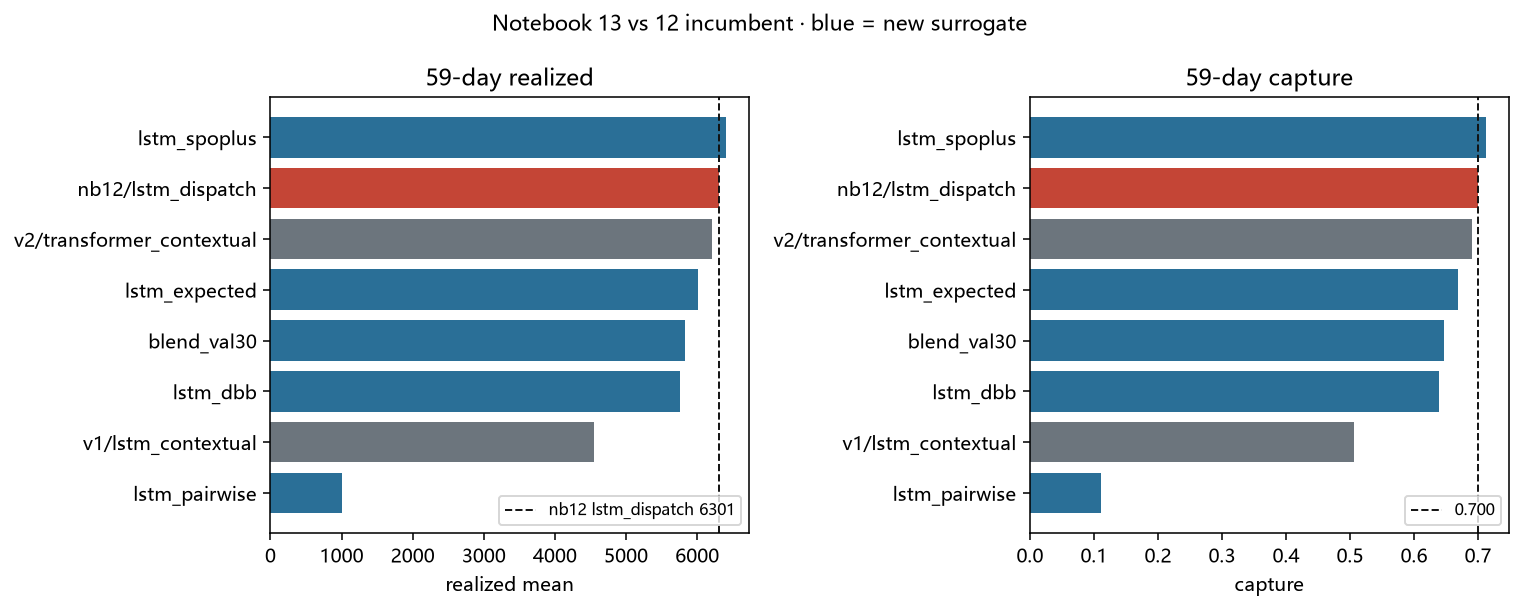

In [5]:
order = compare.sort_values('realized_profit_mean', ascending=False)
colors = ['#2a6f97' if src == 'nb13' else '#c44536' if src == 'nb12' else '#6c757d' for src in order['source']]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].barh(order['recipe'], order['realized_profit_mean'], color=colors)
axes[0].axvline(MONEY_LINE, color='#111', linestyle='--', linewidth=1, label='nb12 lstm_dispatch 6301')
axes[0].set_xlabel('realized mean')
axes[0].set_title('59-day realized')
axes[0].invert_yaxis()
axes[0].legend(loc='lower right', fontsize=8)
axes[1].barh(order['recipe'], order['capture'], color=colors)
axes[1].axvline(MONEY_CAPTURE, color='#111', linestyle='--', linewidth=1, label='0.700')
axes[1].set_xlabel('capture')
axes[1].set_title('59-day capture')
axes[1].invert_yaxis()
axes[1].legend(loc='lower right', fontsize=8)
fig.suptitle('Notebook 13 vs 12 incumbent · blue = new surrogate', fontsize=11)
fig.tight_layout()
p1 = FIGURES / 'nb13_fig1_realized_capture.png'
fig.savefig(p1, dpi=140, bbox_inches='tight')
plt.close(fig)
print(p1.relative_to(REPO_ROOT))
show_figure(p1)


outputs\notebooks\figures\nb13_fig2_pred_vs_realized.png


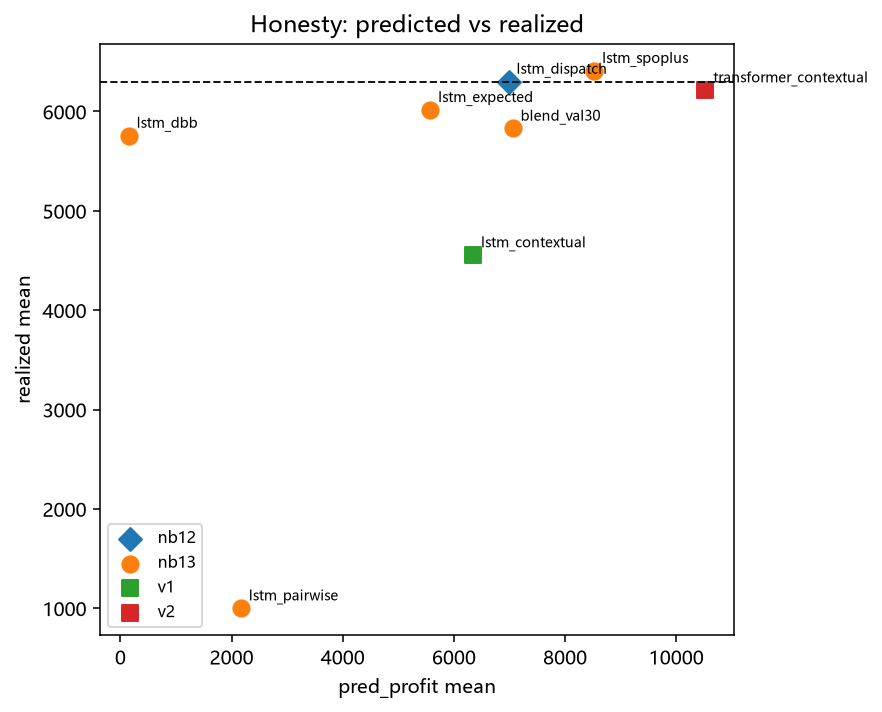

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
for src, sub in compare.groupby('source'):
    marker = 'o' if src == 'nb13' else 'D' if src == 'nb12' else 's'
    ax.scatter(sub['pred_profit_mean'], sub['realized_profit_mean'], s=70, marker=marker, label=src)
    for _, row in sub.iterrows():
        ax.annotate(str(row['recipe']).split('/')[-1], (row['pred_profit_mean'], row['realized_profit_mean']), fontsize=7, xytext=(4, 4), textcoords='offset points')
ax.axhline(MONEY_LINE, color='#111', linestyle='--', linewidth=1)
ax.set_xlabel('pred_profit mean')
ax.set_ylabel('realized mean')
ax.set_title('Honesty: predicted vs realized')
ax.legend(fontsize=8)
fig.tight_layout()
p2 = FIGURES / 'nb13_fig2_pred_vs_realized.png'
fig.savefig(p2, dpi=140, bbox_inches='tight')
plt.close(fig)
print(p2.relative_to(REPO_ROOT))
show_figure(p2)


## 2025-12-12：最好的新模型 vs 12 的 LSTM


outputs\notebooks\figures\nb13_fig3_dec12.png


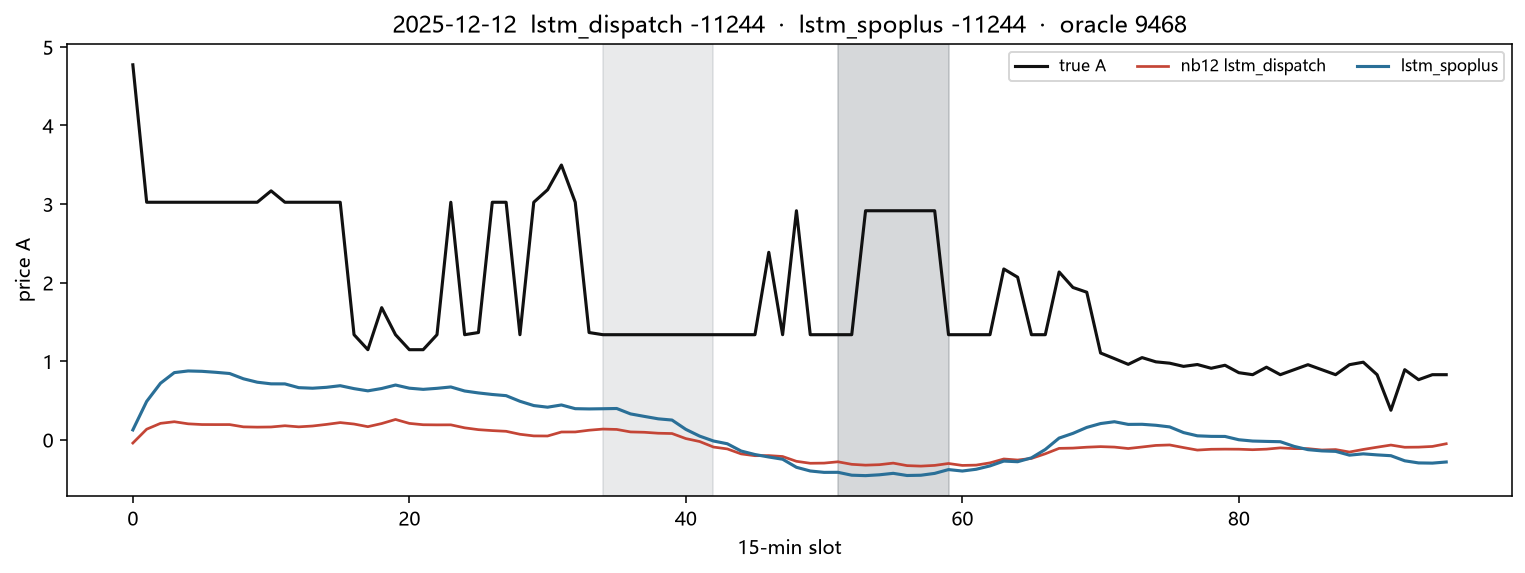

In [7]:
from src.phase_b.dispatch import optimize_day
from src.phase_b.evaluation import score_day

old_pred = pd.read_parquet(REPORT12 / 'predictions.parquet')
new_pred = pd.read_parquet(REPORT / 'predictions.parquet')
best_name = str(best_new['model'])
day = pd.Timestamp('2025-12-12')
old_day = old_pred.loc[pd.to_datetime(old_pred['times']).dt.normalize() == day]
new_day = new_pred.loc[pd.to_datetime(new_pred['times']).dt.normalize() == day]
actual = old_day['A'].to_numpy(dtype=float)
old = old_day['lstm_dispatch'].to_numpy(dtype=float)
new = new_day[best_name].to_numpy(dtype=float)
slots = np.arange(96)
old_dec = optimize_day(old)
new_dec = optimize_day(new)
ora = optimize_day(actual)
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(slots, actual, color='#111', linewidth=1.6, label='true A')
ax.plot(slots, old, color='#c44536', linewidth=1.4, label='nb12 lstm_dispatch')
ax.plot(slots, new, color='#2a6f97', linewidth=1.6, label=best_name)
if ora.tc is not None:
    ax.axvspan(ora.tc, ora.tc + 8, color='#6c757d', alpha=0.15)
    ax.axvspan(ora.td, ora.td + 8, color='#6c757d', alpha=0.28)
ax.set_xlabel('15-min slot')
ax.set_ylabel('price A')
ax.set_title(
    f'2025-12-12  lstm_dispatch {score_day(actual, old_dec.power):.0f}  ·  '
    f'{best_name} {score_day(actual, new_dec.power):.0f}  ·  oracle {score_day(actual, ora.power):.0f}'
)
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
p3 = FIGURES / 'nb13_fig3_dec12.png'
fig.savefig(p3, dpi=140, bbox_inches='tight')
plt.close(fig)
print(p3.relative_to(REPO_ROOT))
show_figure(p3)


## 30 日选格（holdout 没用过）


kind,label,val30_realized,chosen
blend,blend r0.0 l0.0 m1.0,8530.561915,True
blend,blend r0.0 l0.5 m0.5,8201.440184,False
blend,blend r0.0 l0.25 m0.75,8169.997584,False
blend,blend r0.0 l0.75 m0.25,8137.797238,False
blend,blend r0.25 l0.75 m0.0,7824.929954,False
blend,blend r0.25 l0.25 m0.5,7771.124667,False
blend,blend r0.25 l0.5 m0.25,7756.258190,False
blend,blend r0.25 l0.0 m0.75,7713.706605,False
blend,blend r0.0 l1.0 m0.0,7675.974367,False
blend,blend r0.5 l0.5 m0.0,7057.315779,False


outputs\notebooks\figures\nb13_fig4_val30_grid.png


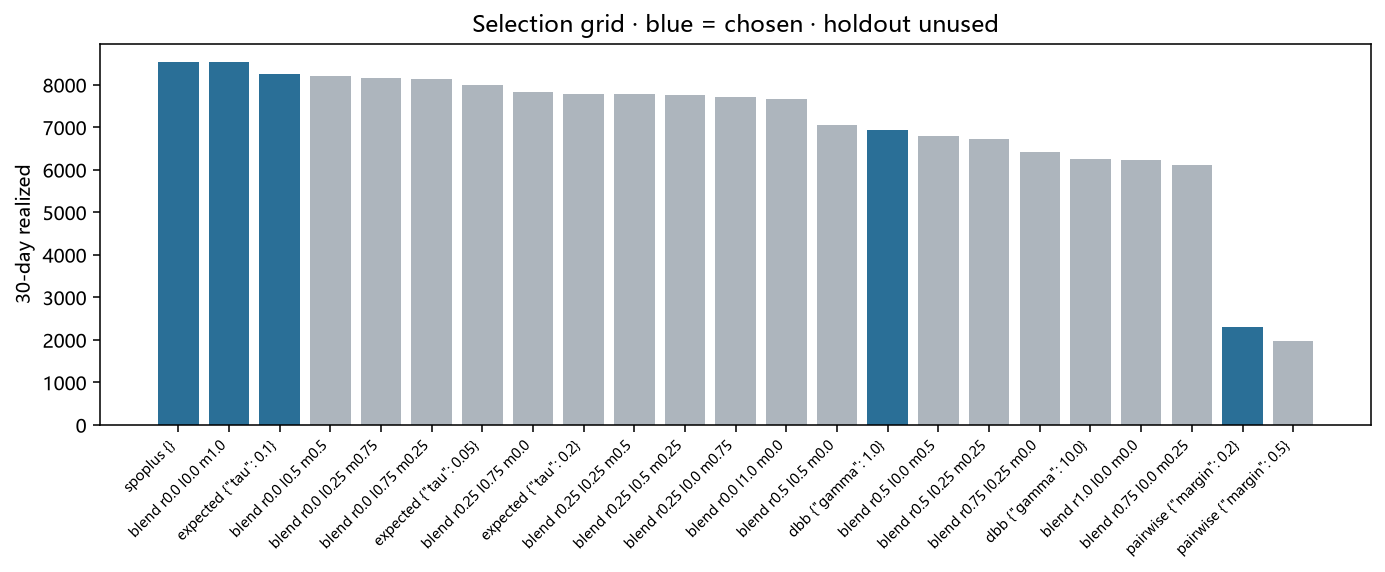

In [8]:
grid_rows = []
for kind, payload in selection.items():
    chosen = payload.get('params', {})
    for point in payload.get('grid', []):
        if kind == 'blend':
            label = f"blend r{point.get('w_ridge')} l{point.get('w_lgb')} m{point.get('w_lstm')}"
            realized = point.get('val30_realized')
            is_chosen = (
                abs(point.get('w_ridge', -1) - chosen.get('w_ridge', -2)) < 1e-9
                and abs(point.get('w_lgb', -1) - chosen.get('w_lgb', -2)) < 1e-9
            )
        else:
            params = point.get('params', point)
            label = f"{kind} {json.dumps(params, sort_keys=True)}"
            realized = point.get('val30_realized')
            is_chosen = params == chosen and point.get('status', 'ok') == 'ok'
        grid_rows.append({'kind': kind, 'label': label, 'val30_realized': realized, 'chosen': is_chosen})
grid = pd.DataFrame(grid_rows)
grid = grid[grid['val30_realized'].notna()].copy()
display(grid.sort_values(['kind', 'val30_realized'], ascending=[True, False]).head(24).style.hide(axis='index'))

plot = grid.copy()
if len(plot) > 24:
    plot = pd.concat([
        plot[plot['chosen']],
        plot.sort_values('val30_realized', ascending=False).head(18),
    ]).drop_duplicates(subset=['label'])
plot = plot.sort_values('val30_realized', ascending=False)
fig, ax = plt.subplots(figsize=(10, 4.2))
bar_colors = ['#2a6f97' if chosen else '#adb5bd' for chosen in plot['chosen']]
ax.bar(np.arange(len(plot)), plot['val30_realized'].astype(float), color=bar_colors)
ax.set_xticks(np.arange(len(plot)))
ax.set_xticklabels(plot['label'], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('30-day realized')
ax.set_title('Selection grid · blue = chosen · holdout unused')
fig.tight_layout()
p4 = FIGURES / 'nb13_fig4_val30_grid.png'
fig.savefig(p4, dpi=140, bbox_inches='tight')
plt.close(fig)
print(p4.relative_to(REPO_ROOT))
show_figure(p4)


## 59 天不是新冠军

Holdout 已在 11、12 露过面。本册只回答：换掉单窗 CE 之后，Mandi / SPO+ / DBB / 集成有没有比 `lstm_dispatch` 更赚钱。不刷新总榜，不改 Phase B，不在 59 天上再拧超参。SPO+ 这一路是端到端 LSTM，不是 `decision_guided_agent_v1` 里失败的 P01 校准器。
